## Decision Tree, Support Vector Machines and Unsupervised Learning

### STAT 3612 (2026 Spring)

In this tutorial, we will quickly cover three parts we have learned: decision tree, support vector machines, and unsupervised learning.

### Decision Tree

Decision Tree Analysis is a general, predictive modelling tool that has applications spanning a number of different areas. In general, decision trees are constructed via an algorithmic approach that identifies ways to split a data set based on different conditions. It is one of the most widely used and practical methods for supervised learning. Decision Trees are a non-parametric supervised learning method used for both classification and regression tasks. The goal is to create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features.

|  Day	 |  Weather |  Temperature |  Humidity |  Wind | Play? |
|---|---|---|---|---|---|
| 1	| Sunny	 | Hot	| High	| Weak | No |
| 2	| Cloudy | Hot	| High	| Weak	| Yes |
| 3	| Sunny	 |Mild 	| Normal |	Strong |	Yes |
| 4	| Cloudy |	Mild |	High |	Strong	| Yes |
| 5	| Rainy	 | Mild	| High	| Strong	| No |
| 6	| Rainy	 |Cool	| Normal |	Strong	| No | 
| 7	| Rainy	 | Mild	| High	| Weak	| Yes |
| 8	| Sunny	 | Hot	| High	| Strong |	No |
| 9	| Cloudy |	Hot	| Normal |	Weak |	Yes |
| 10	| Rainy	 |Mild	| High	| Strong |	No |

Now, you may use this table to decide whether to play or not. But, what if the weather pattern on Saturday does not match with any of rows in the table? This may be a problem. A decision tree would be a great way to represent data like this because it takes into account all the possible paths that can lead to the final decision by following a tree-like structure.

<img src="https://s3-ap-southeast-1.amazonaws.com/he-public-data/Fig%201-18e1a01b.png">

A general algorithm for a decision tree can be described as follows:

1. Pick the best attribute/feature. The best attribute is one which best splits or separates the data.
2. Ask the relevant question.
3. Follow the answer path.
4. Go to step 1 until you arrive to the answer.
5. The best split is one which separates two different labels into two sets.

#### Calculating Information Gain

As stated earlier, information gain is a statistical property that measures how well a given attribute separates the training examples according to their target classification. In the figure below, we can see that an attribute with low information gain (right) splits the data relatively evenly and as a result doesn’t bring us any closer to a decision. Whereas, an attribute with high information gain (left) splits the data into groups with an uneven number of positives and negatives and as a result helps in separating the two from each other.

<img src="https://s3-ap-southeast-1.amazonaws.com/he-public-data/high%20information%20gaine8d3940.png" width=500 height=300>

<img src="https://s3-ap-southeast-1.amazonaws.com/he-public-data/low%20information%20gainef0016c.png" width=500 height=300>

To define information gain precisely, we need to define a measure commonly used in information theory called entropy that measures the level of impurity in a group of examples. Mathematically, it is defined as:
$$
\mathrm{Entropy}: \sum_{i=1} -p_i * \mathrm{log}(p_i)
$$

Now, we will use the scikit-learn library to build the decision tree model. We will be using the iris dataset to build a decision tree classifier. The data set contains information of 3 classes of the iris plant with the following attributes: - sepal length - sepal width - petal length - petal width - class: Iris Setosa, Iris Versicolour, Iris Virginica


In [38]:
# Importing required libraries
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [39]:
#Loading the iris data
data = load_iris()
print('Classes to predict: ', data.target_names)

Classes to predict:  ['setosa' 'versicolor' 'virginica']


There are three classes of iris plants: 'setosa', 'versicolor' and 'virginica'. Now, we have imported the iris data in the variable 'data'. We will now extract the attribute data and the corresponding labels. We can extract the attributes and labels by calling .data and .target as shown below:

In [40]:
# Extracting data attributes
X = data.data
### Extracting target/ class labels
y = data.target

print('Number of examples in the data:', X.shape[0])

Number of examples in the data: 150


In [41]:
# Using the train_test_split to create train and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.25, stratify=y)

In [42]:
# Importing the Decision tree classifier from the sklearn library.
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(criterion = 'entropy')
# Training the decision tree classifier. 
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [43]:
# Predicting labels on the test set.
y_pred =  clf.predict(X_test)

#Importing the accuracy metric from sklearn.metrics library
from sklearn.metrics import accuracy_score
print('Accuracy Score on train data: ', accuracy_score(y_true=y_train, y_pred=clf.predict(X_train)))
print('Accuracy Score on test data: ', accuracy_score(y_true=y_test, y_pred=y_pred))


Accuracy Score on train data:  1.0
Accuracy Score on test data:  0.9210526315789473


[Text(0.4, 0.9285714285714286, 'x[2] <= 2.45\nentropy = 1.585\nsamples = 112\nvalue = [38, 37, 37]'),
 Text(0.3, 0.7857142857142857, 'entropy = 0.0\nsamples = 38\nvalue = [38, 0, 0]'),
 Text(0.35, 0.8571428571428572, 'True  '),
 Text(0.5, 0.7857142857142857, 'x[2] <= 4.85\nentropy = 1.0\nsamples = 74\nvalue = [0, 37, 37]'),
 Text(0.45, 0.8571428571428572, '  False'),
 Text(0.2, 0.6428571428571429, 'x[3] <= 1.65\nentropy = 0.187\nsamples = 35\nvalue = [0, 34, 1]'),
 Text(0.1, 0.5, 'entropy = 0.0\nsamples = 33\nvalue = [0, 33, 0]'),
 Text(0.3, 0.5, 'x[0] <= 6.05\nentropy = 1.0\nsamples = 2\nvalue = [0, 1, 1]'),
 Text(0.2, 0.35714285714285715, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.4, 0.35714285714285715, 'entropy = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.8, 0.6428571428571429, 'x[3] <= 1.7\nentropy = 0.391\nsamples = 39\nvalue = [0, 3, 36]'),
 Text(0.7, 0.5, 'x[2] <= 4.95\nentropy = 1.0\nsamples = 6\nvalue = [0, 3, 3]'),
 Text(0.6, 0.35714285714285715, 'entropy 

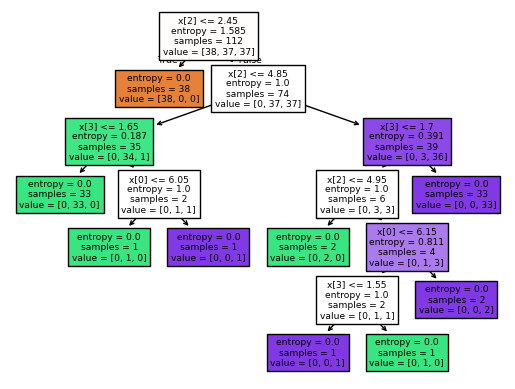

In [44]:
from sklearn.tree import plot_tree

plot_tree(clf, filled=True)

Plot the decision surface of a decision tree trained on pairs of features of the iris dataset.

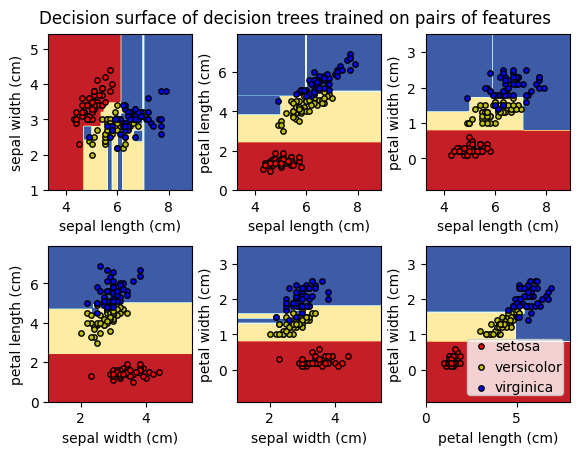

In [45]:
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt

# Parameters
n_classes = 3
plot_colors = "ryb"
plot_step = 0.02


for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3]]):
    # We only take the two corresponding features
    X = data.data[:, pair]
    y = data.target

    # Train
    clf = DecisionTreeClassifier().fit(X, y)

    # Plot the decision boundary
    ax = plt.subplot(2, 3, pairidx + 1)
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)
    DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        cmap=plt.cm.RdYlBu,
        response_method="predict",
        ax=ax,
        xlabel=data.feature_names[pair[0]],
        ylabel=data.feature_names[pair[1]],
    )

    # Plot the training points
    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y == i)
        plt.scatter(
            X[idx, 0],
            X[idx, 1],
            c=color,
            label=data.target_names[i],
            edgecolor="black",
            s=15,
        )

plt.suptitle("Decision surface of decision trees trained on pairs of features")
plt.legend(loc="lower right", borderpad=0, handletextpad=0)
_ = plt.axis("tight")

### Support Vector Machines

To start, we first train a linear SVM and try to understand it.

In [46]:
# we first select two features and two classes from iris for better visualization

# Extracting data attributes
X = data.data
### Extracting target/ class labels
y = data.target

X = X[:, [2, 3]]

# select for 
class_0_index = np.where(y == 1)
class_1_index = np.where(y == 2)
X = np.concatenate((X[class_0_index], X[class_1_index]))
y = np.concatenate((y[class_0_index], y[class_1_index]))

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.25, stratify=y)

In [47]:
from sklearn.svm import SVC

mmc_clf = SVC(kernel="linear", random_state=42)
mmc_clf.fit(X_train, y_train)
mmc_clf.score(X_test, y_test)

0.88

Let's visualize the decision boundary of SVM for deeper understanding.

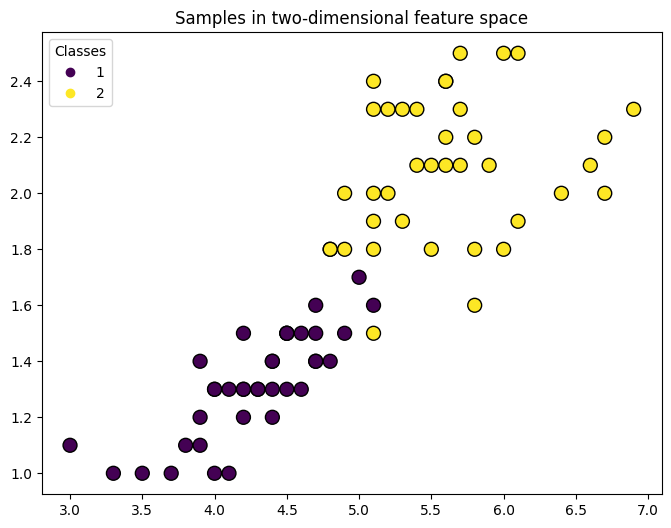

In [48]:
# Plotting settings
fig, ax = plt.subplots(figsize=(8, 6))

# Plot samples by color and add legend
scatter = ax.scatter(X_train[:, 0], X_train[:, 1], s=100, c=y_train, label=y_train, edgecolors="k")
ax.legend(*scatter.legend_elements(), loc="upper left", title="Classes")
ax.set_title("Samples in two-dimensional feature space")
_ = plt.show()

#### Visualize Decision Boundary

We define a function that fits a SVC classifier, allowing the kernel parameter as an input, and then plots the decision boundaries learned by the model using `DecisionBoundaryDisplay`.

In [49]:
from sklearn import svm
from sklearn.inspection import DecisionBoundaryDisplay


def plot_training_data_with_decision_boundary(
    kernel, ax=None, long_title=True, support_vectors=True
):
    # Train the SVC
    clf = svm.SVC(kernel=kernel, gamma=2).fit(X, y)

    # Settings for plotting
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 3))
    # x_min, x_max, y_min, y_max = -3, 3, -3, 3
    # ax.set(xlim=(x_min, x_max), ylim=(y_min, y_max))

    # Plot decision boundary and margins
    common_params = {"estimator": clf, "X": X, "ax": ax}
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="predict",
        plot_method="pcolormesh",
        alpha=0.3,
    )
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="decision_function",
        plot_method="contour",
        levels=[-1, 0, 1],
        colors=["k", "k", "k"],
        linestyles=["--", "-", "--"],
    )

    if support_vectors:
        # Plot bigger circles around samples that serve as support vectors
        ax.scatter(
            clf.support_vectors_[:, 0],
            clf.support_vectors_[:, 1],
            s=150,
            facecolors="none",
            edgecolors="k",
        )

    # Plot samples by color and add legend
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolors="k")
    ax.legend(*scatter.legend_elements(), loc="upper right", title="Classes")
    if long_title:
        ax.set_title(f" Decision boundaries of {kernel} kernel in SVC")
    else:
        ax.set_title(kernel)

    if ax is None:
        plt.show()

#### Linear Kernel

Linear kernel is the dot product of the input samples:
$$
K(x_1, x_2) = X_1^{T}X_2
$$

It is then applied to any combination of two data points (samples) in the dataset. The dot product of the two points determines the cosine_similarity between both points. The higher the value, the more similar the points are.

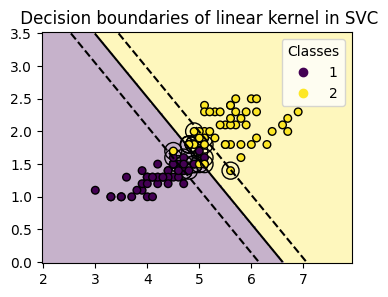

In [50]:
plot_training_data_with_decision_boundary("linear")

#### Polynomial kernel

The polynomial kernel changes the notion of similarity. The kernel function is defined as:
$$
K(x_1, x_2) = (\gamma \cdot x_1^{T}x_2 + r)^d
$$
where d is the degree (degree) of the polynomial, 
 $\gamma$ controls the influence of each individual training sample on the decision boundary and 
 r is the bias term (coef0) that shifts the data up or down.


In [51]:
mmc_clf = SVC(kernel="poly", random_state=42)
mmc_clf.fit(X_train, y_train)
mmc_clf.score(X_test, y_test)

0.84

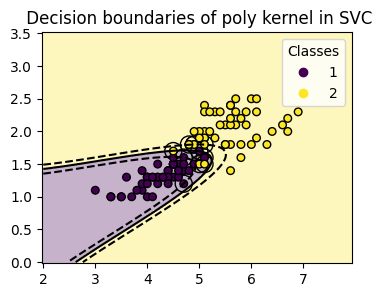

In [52]:
plot_training_data_with_decision_boundary("poly")

#### RBF kernel

The radial basis function (RBF) kernel, also known as the Gaussian kernel, is the default kernel for Support Vector Machines in scikit-learn. It measures similarity between two data points in infinite dimensions and then approaches classification by majority vote. The kernel function is defined as:
$$
K(x_1, x_2) = \mathrm{exp}(-\gamma \cdot ||x_1 - x_2||^2)
$$
where $\gamma$ controls the influence of each individual training sample on the decision boundary.

In [53]:
mmc_clf = SVC(kernel="rbf", random_state=42)
mmc_clf.fit(X_train, y_train)
mmc_clf.score(X_test, y_test)

0.92

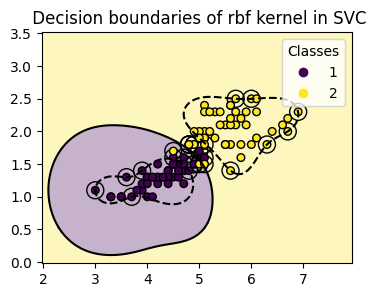

In [54]:
plot_training_data_with_decision_boundary("rbf")

#### Sigmoid kernel

The sigmoid kernel function is defined as:
$$
K(x_1, x_2) = \mathrm{tanh}(\gamma \cdot x_1^Tx_2 + r)
$$
where the kernel coefficient $\gamma$ controls the influence of each individual training sample on the decision boundary and 
r is the bias term (coef0) that shifts the data up or down.

In [55]:
mmc_clf = SVC(kernel="sigmoid", random_state=42)
mmc_clf.fit(X_train, y_train)
mmc_clf.score(X_test, y_test)

0.48

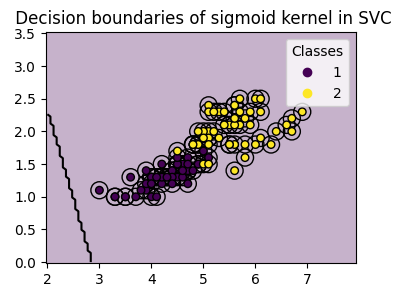

In [56]:
plot_training_data_with_decision_boundary("sigmoid")

#### Conclusion
In this example, we have visualized the decision boundaries trained with the provided dataset. The plots serve as an intuitive demonstration of how different kernels utilize the training data to determine the classification boundaries.

The hyperplanes and margins, although computed indirectly, can be imagined as planes in the transformed feature space. However, in the plots, they are represented relative to the original feature space, resulting in curved decision boundaries for the polynomial, RBF, and sigmoid kernels.

Please note that the plots do not evaluate the individual kernel’s accuracy or quality. They are intended to provide a visual understanding of how the different kernels use the training data.

#### Analysis on XOR dataset

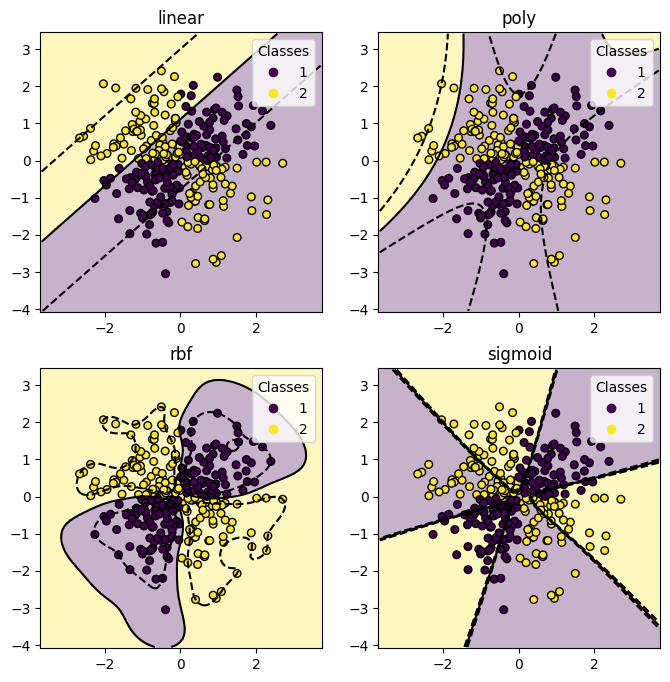

In [57]:
xx, yy = np.meshgrid(np.linspace(-3, 3, 500), np.linspace(-3, 3, 500))
np.random.seed(0)
X = np.random.randn(300, 2)
y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0)

_, ax = plt.subplots(2, 2, figsize=(8, 8))
args = dict(long_title=False, support_vectors=False)
plot_training_data_with_decision_boundary("linear", ax[0, 0], **args)
plot_training_data_with_decision_boundary("poly", ax[0, 1], **args)
plot_training_data_with_decision_boundary("rbf", ax[1, 0], **args)
plot_training_data_with_decision_boundary("sigmoid", ax[1, 1], **args)
plt.show()

### Unsupervised Learning

This example shows a well known decomposition technique known as Principal Component Analysis (PCA) on the Iris dataset.

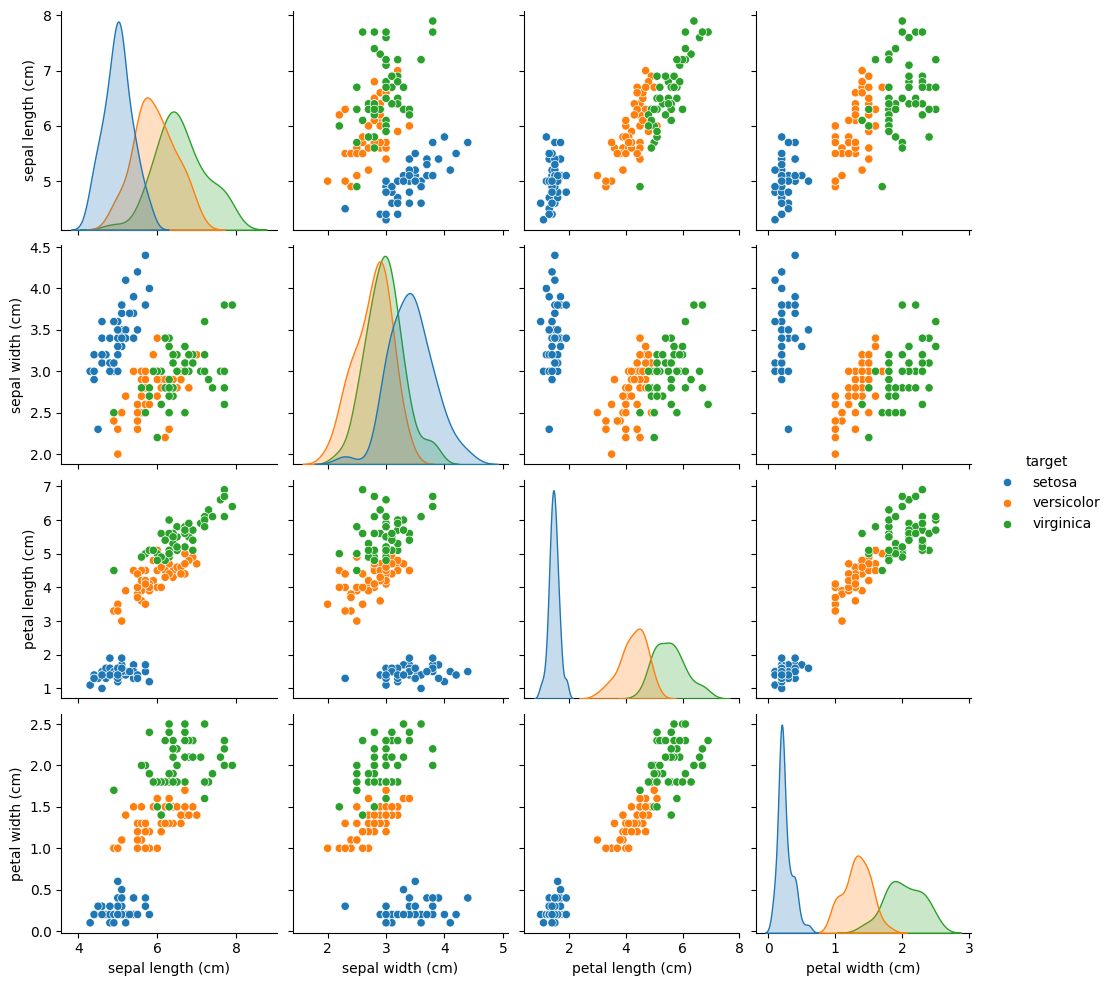

In [58]:
# Let’s first plot the pairs of features of the Iris dataset.
import seaborn as sns
from sklearn import datasets

iris = datasets.load_iris(as_frame=True)

# Rename classes using the iris target names
iris.frame["target"] = iris.target_names[iris.target]
_ = sns.pairplot(iris.frame, hue="target")

Each data point on each scatter plot refers to one of the 150 iris flowers in the dataset, with the color indicating their respective type (Setosa, Versicolor, and Virginica).

You can already see a pattern regarding the Setosa type, which is easily identifiable based on its short and wide sepal. Only considering these two dimensions, sepal width and length, there’s still overlap between the Versicolor and Virginica types.

The diagonal of the plot shows the distribution of each feature. We observe that the petal width and the petal length are the most discriminant features for the three types.

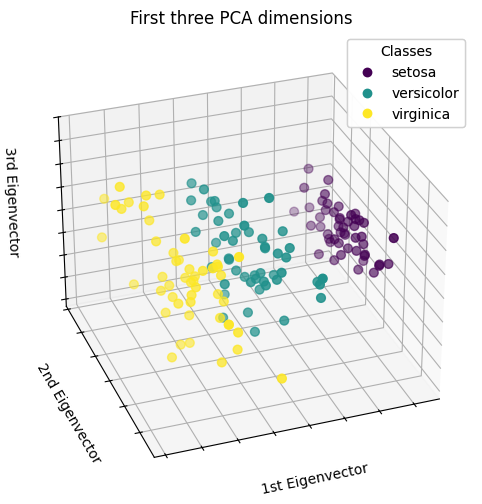

In [59]:
# visualize principal components
import matplotlib.pyplot as plt

# unused but required import for doing 3d projections with matplotlib < 3.2
import mpl_toolkits.mplot3d  # noqa: F401

from sklearn.decomposition import PCA

fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

X_reduced = PCA(n_components=3).fit_transform(iris.data)
scatter = ax.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    X_reduced[:, 2],
    c=iris.target,
    s=40,
)

ax.set(
    title="First three PCA dimensions",
    xlabel="1st Eigenvector",
    ylabel="2nd Eigenvector",
    zlabel="3rd Eigenvector",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

# Add a legend
legend1 = ax.legend(
    scatter.legend_elements()[0],
    iris.target_names.tolist(),
    loc="upper right",
    title="Classes",
)
ax.add_artist(legend1)

plt.show()

#### Comparison between PCA and LDA

The Iris dataset represents 3 kind of Iris flowers (Setosa, Versicolour and Virginica) with 4 attributes: sepal length, sepal width, petal length and petal width.

Principal Component Analysis (PCA) applied to this data identifies the combination of attributes (principal components, or directions in the feature space) that account for the most variance in the data. Here we plot the different samples on the 2 first principal components.

Linear Discriminant Analysis (LDA) tries to identify attributes that account for the most variance between classes. In particular, LDA, in contrast to PCA, is a supervised method, using known class labels.

explained variance ratio (first two components): [0.92461872 0.05306648]


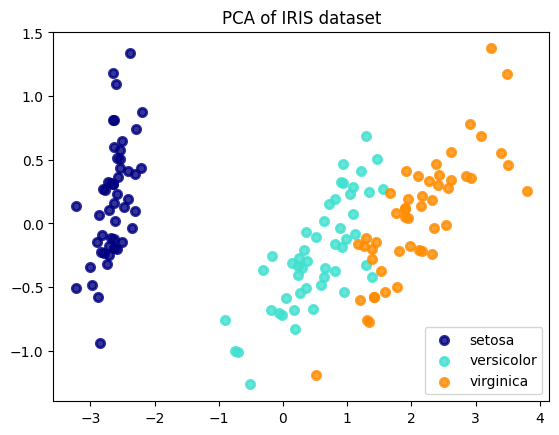

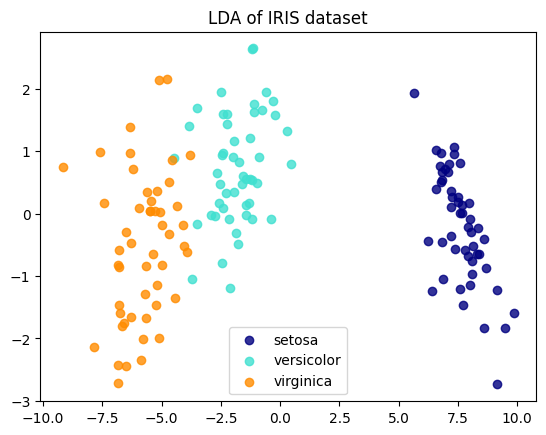

In [60]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

X = iris.data
y = iris.target
target_names = iris.target_names

pca = PCA(n_components=2)
X_r = pca.fit(X).transform(X)

lda = LinearDiscriminantAnalysis(n_components=2)
X_r2 = lda.fit(X, y).transform(X)

# Percentage of variance explained for each components
print(
    "explained variance ratio (first two components): %s"
    % str(pca.explained_variance_ratio_)
)

plt.figure()
colors = ["navy", "turquoise", "darkorange"]
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(
        X_r[y == i, 0], X_r[y == i, 1], color=color, alpha=0.8, lw=lw, label=target_name
    )
plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.title("PCA of IRIS dataset")

plt.figure()
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(
        X_r2[y == i, 0], X_r2[y == i, 1], alpha=0.8, color=color, label=target_name
    )
plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.title("LDA of IRIS dataset")

plt.show()

#### Bonus: Kernel PCA

This example shows the difference between the Principal Components Analysis (PCA) and its kernelized version (KernelPCA).

On the one hand, we show that KernelPCA is able to find a projection of the data which linearly separates them while it is not the case with PCA.

**PCA vs KernelPCA**

Load simulated data:

In [61]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

X, y = make_circles(n_samples=1_000, factor=0.3, noise=0.05, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

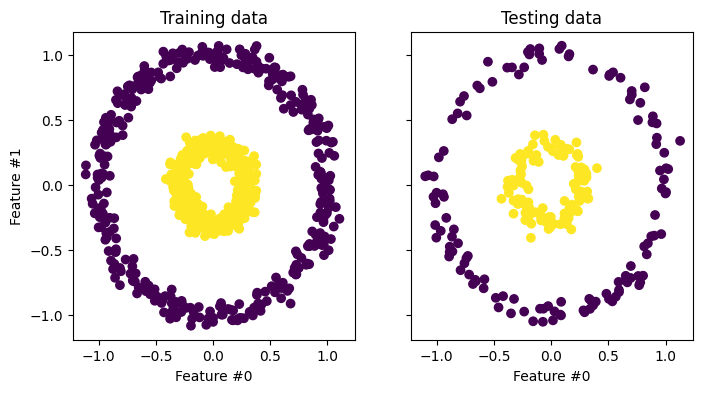

In [62]:
import matplotlib.pyplot as plt

_, (train_ax, test_ax) = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(8, 4))

train_ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
train_ax.set_ylabel("Feature #1")
train_ax.set_xlabel("Feature #0")
train_ax.set_title("Training data")

test_ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test)
test_ax.set_xlabel("Feature #0")
_ = test_ax.set_title("Testing data")

The samples from each class cannot be linearly separated: there is no straight line that can split the samples of the inner set from the outer set.

Now, we will use PCA with and without a kernel to see what is the effect of using such a kernel. The kernel used here is a radial basis function (RBF) kernel.

In [63]:
from sklearn.decomposition import PCA, KernelPCA

pca = PCA(n_components=2)
kernel_pca = KernelPCA(
    n_components=None, kernel="rbf", gamma=10, fit_inverse_transform=True, alpha=0.1
)

X_test_pca = pca.fit(X_train).transform(X_test)
X_test_kernel_pca = kernel_pca.fit(X_train).transform(X_test)

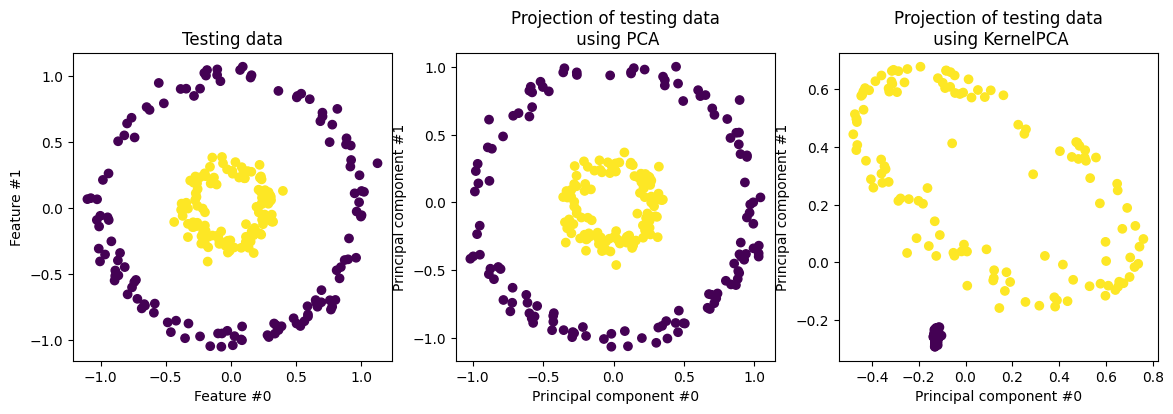

In [64]:
fig, (orig_data_ax, pca_proj_ax, kernel_pca_proj_ax) = plt.subplots(
    ncols=3, figsize=(14, 4)
)

orig_data_ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test)
orig_data_ax.set_ylabel("Feature #1")
orig_data_ax.set_xlabel("Feature #0")
orig_data_ax.set_title("Testing data")

pca_proj_ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test)
pca_proj_ax.set_ylabel("Principal component #1")
pca_proj_ax.set_xlabel("Principal component #0")
pca_proj_ax.set_title("Projection of testing data\n using PCA")

kernel_pca_proj_ax.scatter(X_test_kernel_pca[:, 0], X_test_kernel_pca[:, 1], c=y_test)
kernel_pca_proj_ax.set_ylabel("Principal component #1")
kernel_pca_proj_ax.set_xlabel("Principal component #0")
_ = kernel_pca_proj_ax.set_title("Projection of testing data\n using KernelPCA")

Using a kernel allows to make a non-linear projection. Here, by using an RBF kernel, we expect that the projection will unfold the dataset while keeping approximately preserving the relative distances of pairs of data points that are close to one another in the original space.